#### Práctica 2: El problema de regresión lineal

Regresión lineal bajo la óptica de la optimización no lineal (from scratch)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Generamos 100 instaces con una sola caracteristica
np.random.seed(42)

X = 2 * np.random.rand(100, 1)

y = 4 + 3 * X + np.random.randn(100, 1)  # Le añadimos error


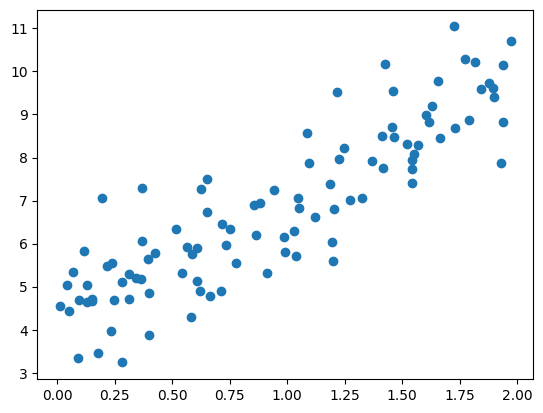

In [3]:
plt.scatter(X, y)
plt.show()

In [4]:
X_b = np.c_[np.ones((100,1)), X]

In [5]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [6]:
print(f'ththa_best: {theta_best}')

ththa_best: [[4.21509616]
 [2.77011339]]


In [7]:
def predict(x):
    y_hat = theta_best[0] + theta_best[1] * x
    return y_hat

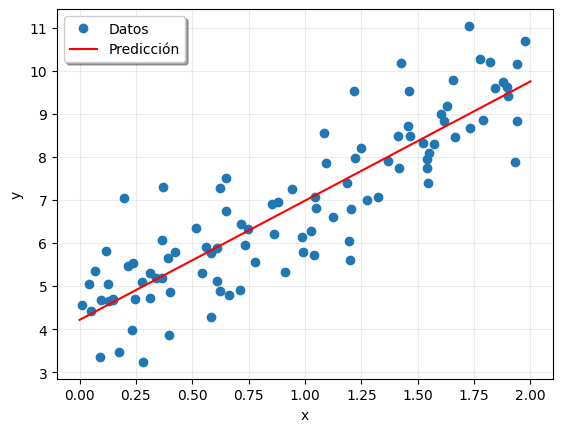

In [8]:
plt.plot(X, y, 'o', label='Datos')

x = np.linspace(0, 2, 100)
y_predict = predict(x)

plt.plot(x, y_predict, 'r', label='Predicción')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(framealpha=1, shadow=True)
plt.grid(alpha=0.25)
plt.show()

#### Regresión lineal en varios módulos de python

## Ajuste de mínimos cuadrados en numpy

In [9]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6) 
# rcond se utiliza para el corte de los autovalores, la condición es que sea mayor que [autovalor(max) * rcond]
# El residuo son los valores de error de |Ax-b| --> hace la norma 2 sum((Ax)j - bj)**2
# rank es el rango de la matriz
# s son los valores singulares

In [10]:
print(f'thetha best = {theta_best_svd}')
print(f'Residuos = {residuals}')
print(f'Rango = {rank}')
print(f'Valores singulares = {s}')

thetha best = [[4.21509616]
 [2.77011339]]
Residuos = [80.6584564]
Rango = 2
Valores singulares = [14.37020392  4.11961067]


In [11]:
print(f'theta_best_pinv = {np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)}')

theta_best_pinv = [[4.21509616]
 [2.77011339]]


### Regresión lienal múltiple en scikit-learn

In [12]:
from sklearn.datasets import make_regression

In [13]:
X_train, y_train, = make_regression(n_samples=1000, n_features=10)

In [14]:
from sklearn import linear_model

In [15]:
regr = linear_model.LinearRegression()

In [16]:
regr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
print(f'Coeficientes = \n {regr.coef_}')

Coeficientes = 
 [48.85611606 55.2975586  95.83485836 54.65137087 75.51430501 20.52575297
 66.63053231 43.50119274 62.32575097 80.37519743]
